### `📤 Import Libraries`.

In [66]:
import os
import io
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.ticker as tkr
import psycopg2
import xlsxwriter
import scipy.stats
import dataframe_image as dfi
import time
import tarfile # Read and write tar archives, including those using gzip, bz2 and lzma compression.
import zipfile # Read or write (.zip) files, or the higher-level functions in shutil
import urllib.request # Open and fetch data from URLs
import warnings
warnings.filterwarnings('ignore')

#==#

from io import BytesIO
from numpy import mean, absolute
from numpy import median, absolute
from sqlalchemy import create_engine
from matplotlib.ticker import FormatStrFormatter, StrMethodFormatter, FuncFormatter, PercentFormatter, MultipleLocator, AutoMinorLocator
from matplotlib import font_manager
from matplotlib import colormaps
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.cbook import boxplot_stats
from pandas.io.formats.style import Styler
from pandas.io.formats.excel import ExcelFormatter
from openpyxl import Workbook
from scipy import stats
from scipy.stats import norm # Normalisation of data
from scipy.stats import trim_mean
from statistics import variance
from statistics import stdev
from sklearn import metrics
from sklearn.linear_model import LinearRegression # Statistical method for predicting an outcome based on one or more influencing factors
from sklearn.linear_model import LogisticRegression # Statistical method for predicting binary classes
from sklearn.model_selection import train_test_split # Split arrays or matrices into random train and test subsets.
from sklearn.preprocessing import StandardScaler # Standardise data
from sklearn.cluster import KMeans # KMeans method from sklearn to build the K-Means model
from yellowbrick.cluster import KElbowVisualizer # KElbowVisualizer to visualise K-Means model performance
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from fpdf import FPDF
from PIL import Image
from IPython.display import HTML, display
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from datetime import timedelta # Represent the difference between two datetime objects.
from pathlib import Path

#==#

# Time series and forecasting libraries
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose # Use for seasonal sales data
import statsmodels.api as sm

# For advanced forecasting
from prophet import Prophet  # Requires `pip install prophet`

# Model evaluation
from sklearn.metrics import confusion_matrix # Evaluate the accuracy of a classification.
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

#==#

import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA

#==#

# Apriori algorithm and association rule mining libraries
import networkx as nx # Python package for the creation, manipulation, and study of the structure, dynamics, and functions of complex networks.
from mlxtend.frequent_patterns import apriori, association_rules # Get frequent itemsets from a one-hot DataFrame, Generates a DataFrame of association rules including the metrics 'score', 'confidence', and 'lift'
from mlxtend.preprocessing import TransactionEncoder # Encoder class for transaction data in Python lists

#==#

from lifetimes import BetaGeoFitter, GammaGammaFitter # BG/NBD + Gamma-Gamma model for Predicting Customer Lifetime Value (CLTV)
from lifetimes.utils import summary_data_from_transaction_data

#==#

# pd.options.display.max_columns = 100
# pd.set_option('display.max_columns', 100)

# Show all columns
pd.set_option('display.max_columns', None)

# Show all rows
pd.set_option('display.max_rows', None)

# Prevent line wrapping of wide columns (for cleaner display)
pd.set_option('display.expand_frame_repr', False)

# Display nicely
pd.set_option('display.max_colwidth', None)

#==#

%matplotlib inline

In [67]:
# from pathlib import Path # Object-oriented filesystem path handling
# import tarfile # Read and write tar archives, including those using gzip, bz2 and lzma compression.
# import zipfile # Read or write (.zip) files, or the higher-level functions in shutil
# import urllib.request # Open and fetch data from URLs

### `📥 Load Dataframe`.

In [68]:
# Define path to california housing market data analysis file
file_path = os.path.expanduser("~/Python-Documents/os/CSV Files/housing.csv")

# Read and copy data
read_csv = pd.read_csv(file_path)
housing_full = read_csv.copy()

# Display first 2 rows
housing_full.head(2)

#==#

# # Load the dataset
# file_path = r"\Users\tailb\Python-Documents\os\CSV Files\housing.csv"

# # Read and copy data
# read_csv = pd.read_csv(file_path)
# housing = read_csv.copy()

# # Display first 2 rows
# housing_full.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY


In [69]:
# # Load dataframe and display first 5 rows.
# def load_housing_data():
#     tarball_path = Path("datasets/housing.tgz")
#     if not tarball_path.is_file():
#         Path("datasets").mkdir(parents=True, exist_ok=True)
#         # url = "https://github.com/ageron/data/raw/main/housing.tgz"
#         # url = "https://github.com/ageron/data/raw/refs/heads/main/housing.tgz"
#         url = "https://github.com/ageron/data/blob/main/housing/housing.tgz"
#         urllib.request.urlretrieve(url, tarball_path)
#         with tarfile.open(tarball_path) as housing_tarball:
#             housing_tarball.extractall(path="datasets", filter="data")
#     return pd.read_csv(Path("datasets/housing/housing.csv"))
# housing_full = load_housing_data()
# housing_full.head()

# # https://github.com/ageron/data/raw/refs/heads/main/housing.tgz

### `🧼 Clean Dataframe`.

#### `Add Engineered Columns`.

In [70]:
# Add engineered columns
housing_full["rooms_per_house"] = housing_full["total_rooms"] / housing_full["households"]

housing_full["bedrooms_ratio"] = housing_full["total_bedrooms"]/ housing_full["total_rooms"]

housing_full["people_per_house"] = housing_full["population"] / housing_full["households"]

housing_full['income_per_person'] = housing_full['median_income'] / housing_full["people_per_house"]     # median_income / people_per_house — affordability metric

housing_full['rooms_per_person'] = housing_full["total_rooms"] / housing_full["population"]      # total_rooms / population — density metric

housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_house,bedrooms_ratio,people_per_house,income_per_person,rooms_per_person
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556,3.257687,2.732919
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842,3.934608,2.956685
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260,2.589838,2.957661
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945,2.214765,2.283154
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467,1.763125,2.879646


#### `Reorder Columns`.

In [71]:
# Reorder columns
# housing_full = housing_full[['longitude', 'latitude', 'population', 'households', 'total_rooms', 'total_bedrooms',
# 'people_per_house', 'rooms_per_house', 'bedrooms_ratio','housing_median_age', 'median_income', 'median_house_value', 'ocean_proximity']]

housing_full = housing_full[['longitude', 'latitude', 'population', 'households', 'total_rooms', 'total_bedrooms',
'people_per_house', 'rooms_per_house', 'rooms_per_person', 'income_per_person','bedrooms_ratio', 'housing_median_age', 'median_income', 'median_house_value', 'ocean_proximity']]

#### `Check For Null/Missing Values`.

In [72]:
# Display info about dataframe.
housing_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   population          20640 non-null  float64
 3   households          20640 non-null  float64
 4   total_rooms         20640 non-null  float64
 5   total_bedrooms      20433 non-null  float64
 6   people_per_house    20640 non-null  float64
 7   rooms_per_house     20640 non-null  float64
 8   rooms_per_person    20640 non-null  float64
 9   income_per_person   20640 non-null  float64
 10  bedrooms_ratio      20433 non-null  float64
 11  housing_median_age  20640 non-null  float64
 12  median_income       20640 non-null  float64
 13  median_house_value  20640 non-null  float64
 14  ocean_proximity     20640 non-null  object 
dtypes: float64(14), object(1)
memory usage: 2.4+ MB


In [73]:
# Display boolean for null/missing values.
housing_full.isnull().any()

longitude             False
latitude              False
population            False
households            False
total_rooms           False
total_bedrooms         True
people_per_house      False
rooms_per_house       False
rooms_per_person      False
income_per_person     False
bedrooms_ratio         True
housing_median_age    False
median_income         False
median_house_value    False
ocean_proximity       False
dtype: bool

In [74]:
# # Display sum of null/missing values.
housing_full.isnull().sum()

longitude               0
latitude                0
population              0
households              0
total_rooms             0
total_bedrooms        207
people_per_house        0
rooms_per_house         0
rooms_per_person        0
income_per_person       0
bedrooms_ratio        207
housing_median_age      0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [75]:
# Display percentage of null/missing values per column.
display_null_percs = (housing_full.isnull().sum() / len(housing_full))
print(display_null_percs.apply(lambda x: f'{x:,.3%}'))

# # print(display_null_percs.map('{:.3%}'.format))

longitude             0.000%
latitude              0.000%
population            0.000%
households            0.000%
total_rooms           0.000%
total_bedrooms        1.003%
people_per_house      0.000%
rooms_per_house       0.000%
rooms_per_person      0.000%
income_per_person     0.000%
bedrooms_ratio        1.003%
housing_median_age    0.000%
median_income         0.000%
median_house_value    0.000%
ocean_proximity       0.000%
dtype: object


In [76]:
# Display sum of null/missing values and percentage share in rows of specified columns.

# Display sum of null/missing values and percentage share in rows of 'total_bedrooms' column.
A = housing_full[housing_full["total_bedrooms"].isnull()].shape[0]
# print(f'The number of bedrooms that are null is {A:,.0f}')

tb_missing_count = housing_full["total_bedrooms"].isnull().sum()
tb_missing_pct = tb_missing_count / len(housing_full)
# print(f'{tb_missing_pct:,.2%}')

print(f'The number of bedrooms that have null values is {A:,.0f}, which is {tb_missing_pct:,.2%}')

#==#

# Display sum of null/missing values and percentage share in rows of 'bedrooms_ratio' column.
B = housing_full[housing_full["bedrooms_ratio"].isnull()].shape[0]
# print(f'The number of bedrooms_ratio that have null value is {B:,.0f}')

br_missing_count = housing_full["bedrooms_ratio"].isnull().sum()
br_missing_pct = br_missing_count / len(housing_full)
# print(f'{br_missing_pct:,.2%}')

print(f'The number of bedrooms_ratio that have null values is {B:,.0f}, which is {br_missing_pct:,.2%}')

The number of bedrooms that have null values is 207, which is 1.00%
The number of bedrooms_ratio that have null values is 207, which is 1.00%


<Axes: >

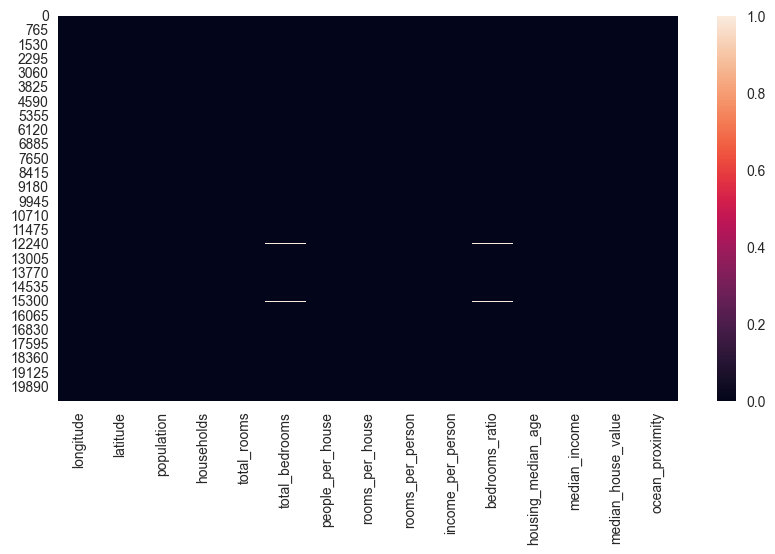

In [77]:
# Visualise missing/null values with seaborn heatmap

# Extract the column names
cols = housing_full.columns

# Plot a heatmap of missing values with seaborn
plt.figure(figsize = (10,5))
sns.heatmap(housing_full[cols].isnull())

In [78]:
# Display null/missing values in rows of 'total_bedrooms' column and 'bedrooms_ratio' column.
housing_full[(housing_full["total_bedrooms"].isnull()) & (housing_full["bedrooms_ratio"].isnull())].loc[:,'longitude':'ocean_proximity'].sample(2)
# housing_full[['total_bedrooms','bedrooms_ratio']]#.sample(2)
# housing_full.loc[:,['total_bedrooms', 'bedrooms_ratio']]#.sample(2)

,longitude,latitude,population,households,total_rooms,total_bedrooms,people_per_house,rooms_per_house,rooms_per_person,income_per_person,bedrooms_ratio,housing_median_age,median_income,median_house_value,ocean_proximity
7619,-118.09,33.89,717.0,219.0,991.0,NaN,3.273973,4.525114,1.382148,1.250041,NaN,42.0,4.0926,164400.0,<1H OCEAN
13086,-118.40,34.17,2945.0,1492.0,6347.0,NaN,1.973861,4.254021,2.155178,1.699461,NaN,24.0,3.3545,221500.0,<1H OCEAN


#### `Interpolate Values To Replace Null/Missing Values In Specified Columns`.

In [79]:
# Interpolate values to replace null/missing values in specified columns.
columns_to_interplolate = ['total_bedrooms', 'bedrooms_ratio']
housing_full[columns_to_interplolate] = housing_full[columns_to_interplolate].interpolate(method='linear', limit_direction='both')

#### `Re-Check For Null/Missing Values`.

In [80]:
# Display boolean for null/missing values.
housing_full.isnull().any()

longitude             False
latitude              False
population            False
households            False
total_rooms           False
total_bedrooms        False
people_per_house      False
rooms_per_house       False
rooms_per_person      False
income_per_person     False
bedrooms_ratio        False
housing_median_age    False
median_income         False
median_house_value    False
ocean_proximity       False
dtype: bool

In [81]:
# Display sum of missing values.
housing_full.isnull().sum()

longitude             0
latitude              0
population            0
households            0
total_rooms           0
total_bedrooms        0
people_per_house      0
rooms_per_house       0
rooms_per_person      0
income_per_person     0
bedrooms_ratio        0
housing_median_age    0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [82]:
# Display percentage of null/missing values per column.
display_null_percs = (housing_full.isnull().sum() / len(housing_full))
print(display_null_percs.apply(lambda x: f'{x:,.3%}'))

# # print(display_null_percs.map('{:.3%}'.format))

longitude             0.000%
latitude              0.000%
population            0.000%
households            0.000%
total_rooms           0.000%
total_bedrooms        0.000%
people_per_house      0.000%
rooms_per_house       0.000%
rooms_per_person      0.000%
income_per_person     0.000%
bedrooms_ratio        0.000%
housing_median_age    0.000%
median_income         0.000%
median_house_value    0.000%
ocean_proximity       0.000%
dtype: object


In [83]:
# Display sum of null/missing values and percentage share in rows specified columns.

# Display sum of null/missing values and percentage share in 'total_bedrooms' column.
A = housing_full[housing_full["total_bedrooms"].isnull()].shape[0]
# print(f'The number of bedrooms that are null is {A:,.0f}')

tb_missing_count = housing_full["total_bedrooms"].isnull().sum()
tb_missing_pct = tb_missing_count / len(housing_full)
# print(f'{tb_missing_pct:,.2%}')

print(f'The number of bedrooms that have null values is {A:,.0f}, which is {tb_missing_pct:,.2%}')

#==#

# Display sum of null/missing values and percentage share in rows of 'bedroom_ratio' column.
B = housing_full[housing_full["bedrooms_ratio"].isnull()].shape[0]
# print(f'The number of bedrooms_ratio that have null value is {B:,.0f}')

br_missing_count = housing_full["bedrooms_ratio"].isnull().sum()
br_missing_pct = br_missing_count / len(housing_full)
# print(f'{br_missing_pct:,.2%}')

print(f'The number of bedrooms_ratio that have null values is {B:,.0f}, which is {br_missing_pct:,.2%}')

The number of bedrooms that have null values is 0, which is 0.00%
The number of bedrooms_ratio that have null values is 0, which is 0.00%


<Axes: >

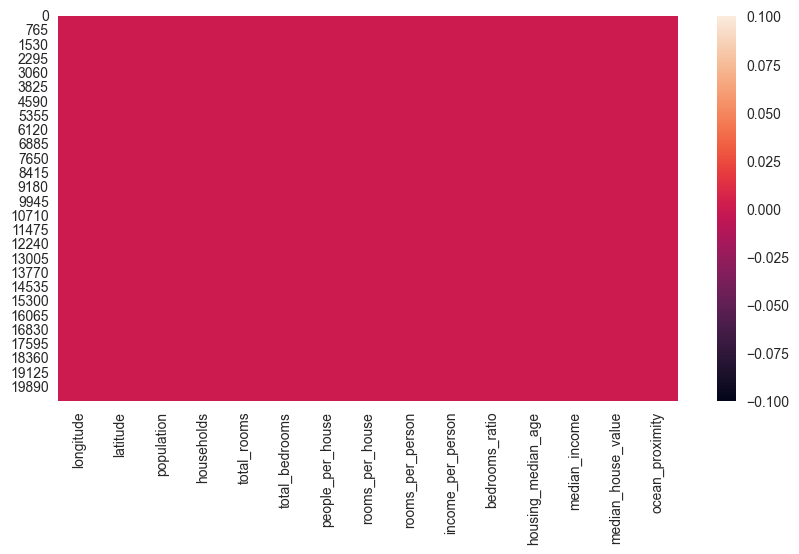

In [84]:
# Visualise missing/null values with seaborn heatmap

# Extract the column names
cols = housing_full.columns

# Plot a heatmap of missing values with seaborn
plt.figure(figsize = (10,5))
sns.heatmap(housing_full[cols].isnull())

In [85]:
# Re-display null/missing values in rows of 'total_bedrooms' column and 'bedrooms_ratio' column.
housing_full[(housing_full["total_bedrooms"].isnull()) & (housing_full["bedrooms_ratio"].isnull())].loc[:,'longitude':'ocean_proximity']
# housing_full[['total_bedrooms','bedrooms_ratio']]
# housing_full.loc[:,['total_bedrooms', 'bedrooms_ratio']]

,longitude,latitude,population,households,total_rooms,total_bedrooms,people_per_house,rooms_per_house,rooms_per_person,income_per_person,bedrooms_ratio,housing_median_age,median_income,median_house_value,ocean_proximity


#### `Check For Duplicated Values`.

In [86]:
# Display boolean of duplicated values.
housing_full.duplicated().any()

False

In [87]:
# Display sum of duplicated values.
housing_full.duplicated().sum()

0

In [88]:
# Display all rows with duplicated values.
housing_full.loc[housing_full.duplicated()]

,longitude,latitude,population,households,total_rooms,total_bedrooms,people_per_house,rooms_per_house,rooms_per_person,income_per_person,bedrooms_ratio,housing_median_age,median_income,median_house_value,ocean_proximity


#### `Review Dataset Features`.

In [89]:
# Re-Display info.
housing_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   population          20640 non-null  float64
 3   households          20640 non-null  float64
 4   total_rooms         20640 non-null  float64
 5   total_bedrooms      20640 non-null  float64
 6   people_per_house    20640 non-null  float64
 7   rooms_per_house     20640 non-null  float64
 8   rooms_per_person    20640 non-null  float64
 9   income_per_person   20640 non-null  float64
 10  bedrooms_ratio      20640 non-null  float64
 11  housing_median_age  20640 non-null  float64
 12  median_income       20640 non-null  float64
 13  median_house_value  20640 non-null  float64
 14  ocean_proximity     20640 non-null  object 
dtypes: float64(14), object(1)
memory usage: 2.4+ MB


In [90]:
# Display data types of each column.
housing_full.dtypes

longitude             float64
latitude              float64
population            float64
households            float64
total_rooms           float64
total_bedrooms        float64
people_per_house      float64
rooms_per_house       float64
rooms_per_person      float64
income_per_person     float64
bedrooms_ratio        float64
housing_median_age    float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [91]:
# Display index.
housing_full.index

RangeIndex(start=0, stop=20640, step=1)

In [92]:
# Display number of rows and columns.
housing_full.shape

(20640, 15)

In [93]:
# Display number of rows x number of columns.
housing_full.size

309600

In [94]:
# Display dataframe numeric statistics.
housing_full.describe()

,longitude,latitude,population,households,total_rooms,total_bedrooms,people_per_house,rooms_per_house,rooms_per_person,income_per_person,bedrooms_ratio,housing_median_age,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,1425.476744,499.539680,2635.763081,538.005572,3.070655,5.429000,1.976970,1.408324,0.213004,28.639486,3.870671,206855.816909
std,2.003532,2.135952,1132.462122,382.329753,2181.615252,420.656621,10.386050,2.474173,1.146020,0.755017,0.057815,12.585558,1.899822,115395.615874
min,-124.350000,32.540000,3.000000,1.000000,2.000000,1.000000,0.692308,0.846154,0.002547,0.008225,0.100000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,787.000000,280.000000,1447.750000,297.000000,2.429741,4.440716,1.522382,0.869633,0.175481,18.000000,2.563400,119600.000000
50%,-118.490000,34.260000,1166.000000,409.000000,2127.000000,435.000000,2.818116,5.229129,1.937936,1.295461,0.203201,29.000000,3.534800,179700.000000
75%,-118.010000,37.710000,1725.000000,605.000000,3148.000000,647.000000,3.282261,6.052381,2.296090,1.775809,0.239683,37.000000,4.743250,264725.000000
max,-114.310000,41.950000,35682.000000,6082.000000,39320.000000,6445.000000,1243.333333,141.909091,55.222222,7.549836,1.000000,52.000000,15.000100,500001.000000


In [95]:
# Display dataframe non-numeric statistics.
housing_full.describe(include=object)

,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


In [96]:
# Preview first two rows
housing_full.head(2)

,longitude,latitude,population,households,total_rooms,total_bedrooms,people_per_house,rooms_per_house,rooms_per_person,income_per_person,bedrooms_ratio,housing_median_age,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,322.0,126.0,880.0,129.0,2.555556,6.984127,2.732919,3.257687,0.146591,41.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,2401.0,1138.0,7099.0,1106.0,2.109842,6.238137,2.956685,3.934608,0.155797,21.0,8.3014,358500.0,NEAR BAY


#### `Multiple 'median_income' &  'income_per_person' by 1000`.

In [97]:
def edit_monetary_values(dataframe, dataframe_columns):
    """
    Multiplies values by 1000 for specified columns where value > 0.
    
    Args:
        dataframe      : The DataFrame to modify.
        dataframe_columns : A list of column names to apply the transformation to.
    
    Returns:
        dataframe : The modified DataFrame.
    """
    for column in dataframe_columns:                                                        # ✅ Iterate over column NAMES
        dataframe[column] = dataframe[column].map(lambda x: x * 1000 if x > 0 else x)       # ✅ Assign changes back
    return dataframe                                                                        # ✅ Return modified DataFrame


# Display rows
housing_full = edit_monetary_values(housing_full, ['median_income', 'income_per_person'])
print(housing_full[['median_income', 'income_per_person']].sample(3))
# housing_full.sample(3)

#==#

# # Multiple 'median_income' &  'income_per_person' by 1000 for real value.
# housing_full['median_income'] = housing_full['median_income'].map(lambda x: x * 1000 if x > 0 else x)
# housing_full['income_per_person'] = housing_full['income_per_person'].map(lambda x: x * 1000 if x > 0 else x)

#==#

# df[df['column']==,!=,<,>'condition'].loc['index_range(e.g - :(all), 1:3, 5:7)':,['insert, column, names']].sample(5)
# df.loc[df['column']==,!=,<,>'condition'].loc['index_range(e.g - :(all), 1:3, 5:7)':,['insert, column, names']].sample(5)

       median_income  income_per_person
14281         3089.3        1542.810401
1474          3091.7        1177.790476
8992          5490.0        2202.878338


### `🧾 Sample Display Two Dataframe Rows`.

In [98]:
# Sample display 2 rows of specified columns.
housing_full.loc[:,'longitude':'ocean_proximity'].sample(2)

,longitude,latitude,population,households,total_rooms,total_bedrooms,people_per_house,rooms_per_house,rooms_per_person,income_per_person,bedrooms_ratio,housing_median_age,median_income,median_house_value,ocean_proximity
15769,-122.68,41.15,224.0,89.0,817.0,206.0,2.516854,9.179775,3.647321,1442.674107,0.252142,32.0,3631.0,90400.0,INLAND
7053,-118.22,34.04,1417.0,325.0,798.0,308.0,4.360000,2.455385,0.563162,325.435780,0.385965,43.0,1418.9,141700.0,<1H OCEAN


### `⧉ Copy Dataframe To Preserve Changes`.

In [99]:
# Copy datframe to preserve changes.
housing = housing_full.copy()

### `💾 Save Modified DataFrame To Python Docs Folder`.

##### `To Excel Files Folder`.

In [100]:
# # 📁 Define base Excel directory
# excel_files_dir = os.path.expanduser("~/Python-Documents/os/Excel Files")

# # 🧱 Create directory if it doesn't exist
# os.makedirs(excel_files_dir, exist_ok=True)

# # ✅ Sort column D (index 3) A-Z before saving
# housing = housing.sort_values(by=housing.columns[3], ascending=True, na_position='last').reset_index(drop=True)

# # 📄 Define full Excel file path
# excel_path = os.path.join(excel_files_dir, "California_Housing_Market_Data_Analysis_modified.xlsx")

# # 💾 Save modified dataset to Excel file
# housing.to_excel(excel_path, index=False)

# # print("Modified Excel file saved to:", excel_path)

# # 🔧 Auto-fit column widths using openpyxl
# wb = openpyxl.load_workbook(excel_path)
# ws = wb.active

# # 🔽 Apply AutoFilter to the entire data range (adds filter dropdowns to header row)
# ws.auto_filter.ref = ws.dimensions

# for col in ws.columns:
#     max_length = 0
#     col_letter = get_column_letter(col[0].column)  # Get column letter (A, B, C...)

#     for cell in col:
#         if cell.value:
#             max_length = max(max_length, len(str(cell.value)))  # Find longest value

#     adjusted_width = max_length + 4  # Add padding
#     ws.column_dimensions[col_letter].width = adjusted_width  # Apply width

# wb.save(excel_path)  # 💾 Save the workbook with adjusted columns

# print("Modified Excel file saved to:", excel_path)

##### `To CSV Files Folder`.

In [101]:
# 📁 Define base CSV directory
csv_files_dir = os.path.expanduser("~/Python-Documents/os/CSV Files")

# 🧱 Create directory if it doesn't exist
os.makedirs(csv_files_dir, exist_ok=True)

# 📄 Define full CSV file path
csv_path = os.path.join(csv_files_dir, "California_Housing_Market_Data_Analysis_modified_1.csv")

# 💾 Save modified dataset to CSV file
housing.to_csv(csv_path, index=False)

print("Modified CSV file saved to:", csv_path)

Modified CSV file saved to: C:\Users\tailb/Python-Documents/os/CSV Files\California_Housing_Market_Data_Analysis_modified_1.csv
